In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
comments = [
    "Amazing product! Loved it.",
    "Worst customer service ever.",
    "Very good quality and fast delivery.",
    "Not satisfied with the product.",
    "Excellent experience.",
    "Terrible packaging.",
    "I will definitely buy again.",
    "Waste of money.",
    "Highly recommended!",
    "Average product."
]

df = pd.DataFrame(comments, columns=['Comment'])

df.head()

,Comment
0,Amazing product! Loved it.
1,Worst customer service ever.
2,Very good quality and fast delivery.
3,Not satisfied with the product.
4,Excellent experience.


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Comment'] = df['Comment'].apply(clean_text)

df.head()

,Comment,Cleaned_Comment
0,Amazing product! Loved it.,amazing product loved
1,Worst customer service ever.,worst customer service ever
2,Very good quality and fast delivery.,good quality fast delivery
3,Not satisfied with the product.,satisfied product
4,Excellent experience.,excellent experience


In [5]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):

    score = sia.polarity_scores(text)

    if score['compound'] >= 0.05:
        return "Positive"

    elif score['compound'] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Cleaned_Comment'].apply(sentiment)

df

,Comment,Cleaned_Comment,Sentiment
0,Amazing product! Loved it.,amazing product loved,Positive
1,Worst customer service ever.,worst customer service ever,Negative
2,Very good quality and fast delivery.,good quality fast delivery,Positive
3,Not satisfied with the product.,satisfied product,Positive
4,Excellent experience.,excellent experience,Positive
5,Terrible packaging.,terrible packaging,Negative
6,I will definitely buy again.,definitely buy,Positive
7,Waste of money.,waste money,Negative
8,Highly recommended!,highly recommended,Positive
9,Average product.,average product,Neutral


In [6]:
df['Sentiment'].value_counts()

Sentiment
Positive    6
Negative    3
Neutral     1
Name: count, dtype: int64

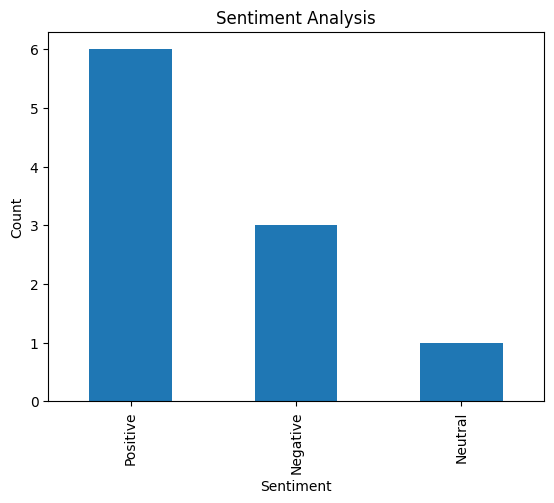

In [7]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [8]:
vectorizer = CountVectorizer(max_features=10)

X = vectorizer.fit_transform(df['Cleaned_Comment'])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

trend = pd.DataFrame({
    'Word':words,
    'Count':counts
})

trend

,Word,Count
0,amazing,1
1,average,1
2,buy,1
3,customer,1
4,definitely,1
5,delivery,1
6,ever,1
7,excellent,1
8,experience,1
9,product,3


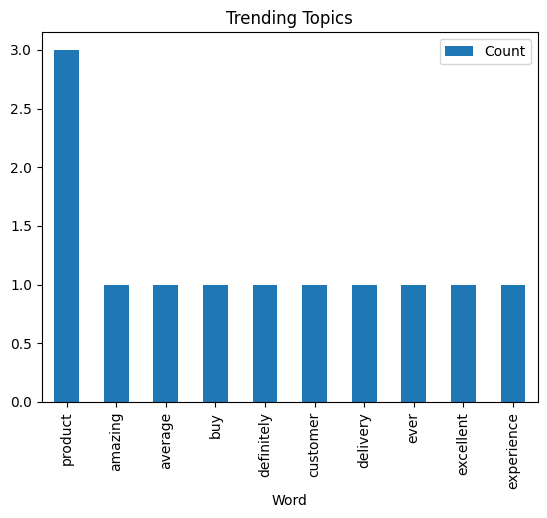

In [9]:
trend.sort_values(by='Count',ascending=False).plot(
x='Word',
y='Count',
kind='bar')

plt.title("Trending Topics")

plt.show()

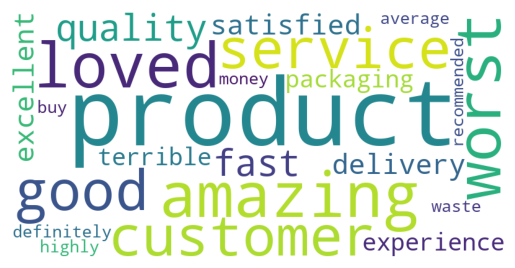

In [10]:
text = " ".join(df['Cleaned_Comment'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [11]:
df.to_csv("Social_Media_Analysis.csv", index=False)